In [1]:
import scanpy as sc
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

from scatlastb_utils.io import read_anndata

/home/mumichae/miniforge3/envs/scFM_benchmark/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
sc.settings.set_figure_params(dpi=72, dpi_save=100, figsize=(4, 4), frameon=False)

# Get data

In [3]:
dataset_name = 'retina_ganglion_ex_midget'
file_path = f'data/cxg/{dataset_name}.h5ad'

In [4]:
adata = read_anndata(
    file_path,
    X='raw/X', # raw, unnormalised counts!
    obs='obs',
    var='var',
    obsm='obsm',
    obsp='obsp',
    dask=True,
    backed=True,
    stride=50_000
)
adata

dask: True, backed: True
chunks: (50000, -1)
Read slot "raw/X", store as "X"...
Read raw/X as backed sparse dask array...
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


Read obsm slots as_dask=False: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 93.80it/s]

Read slot "obsp", store as "obsp"...
shape: (20587, 35475)


AnnData object with n_obs × n_vars = 20587 × 35475
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'RGC_celltype_number', 'study_name', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 

In [5]:
adata.obsm['X_umap_scvi'] = adata.obsm['X_umap']

## Visualise data

In [6]:
colors = [
    'cell_type',
    'author_cell_type',
    'study_name',
    'library_id',
]

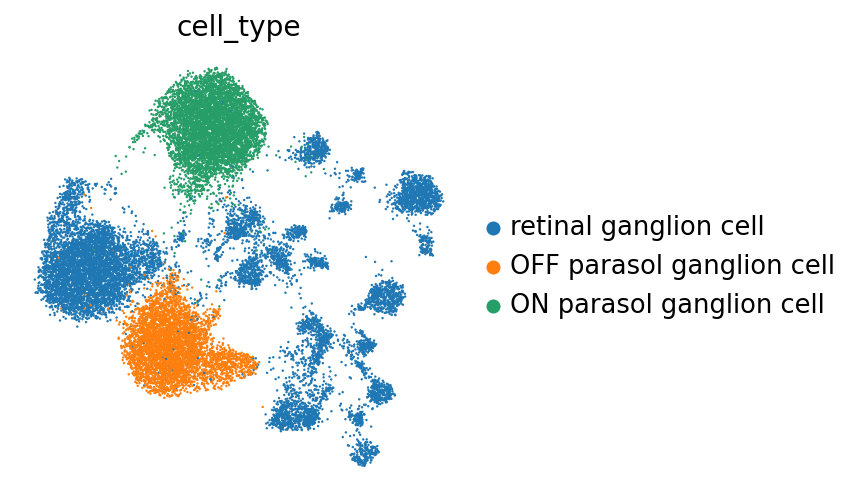

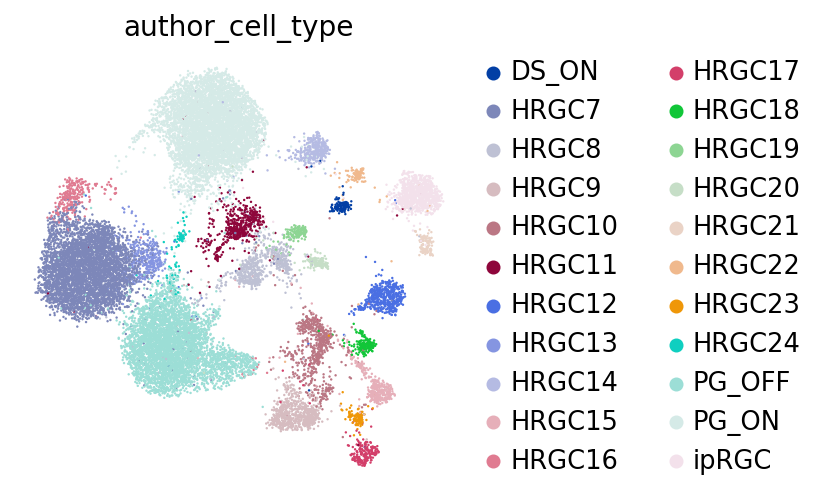

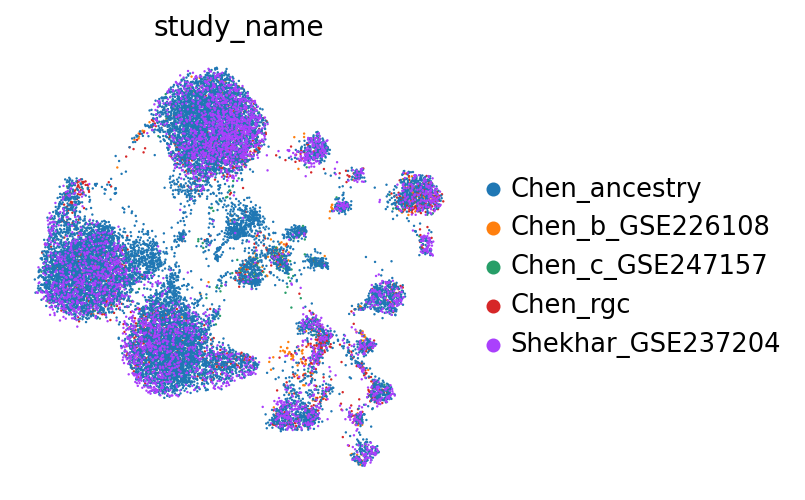

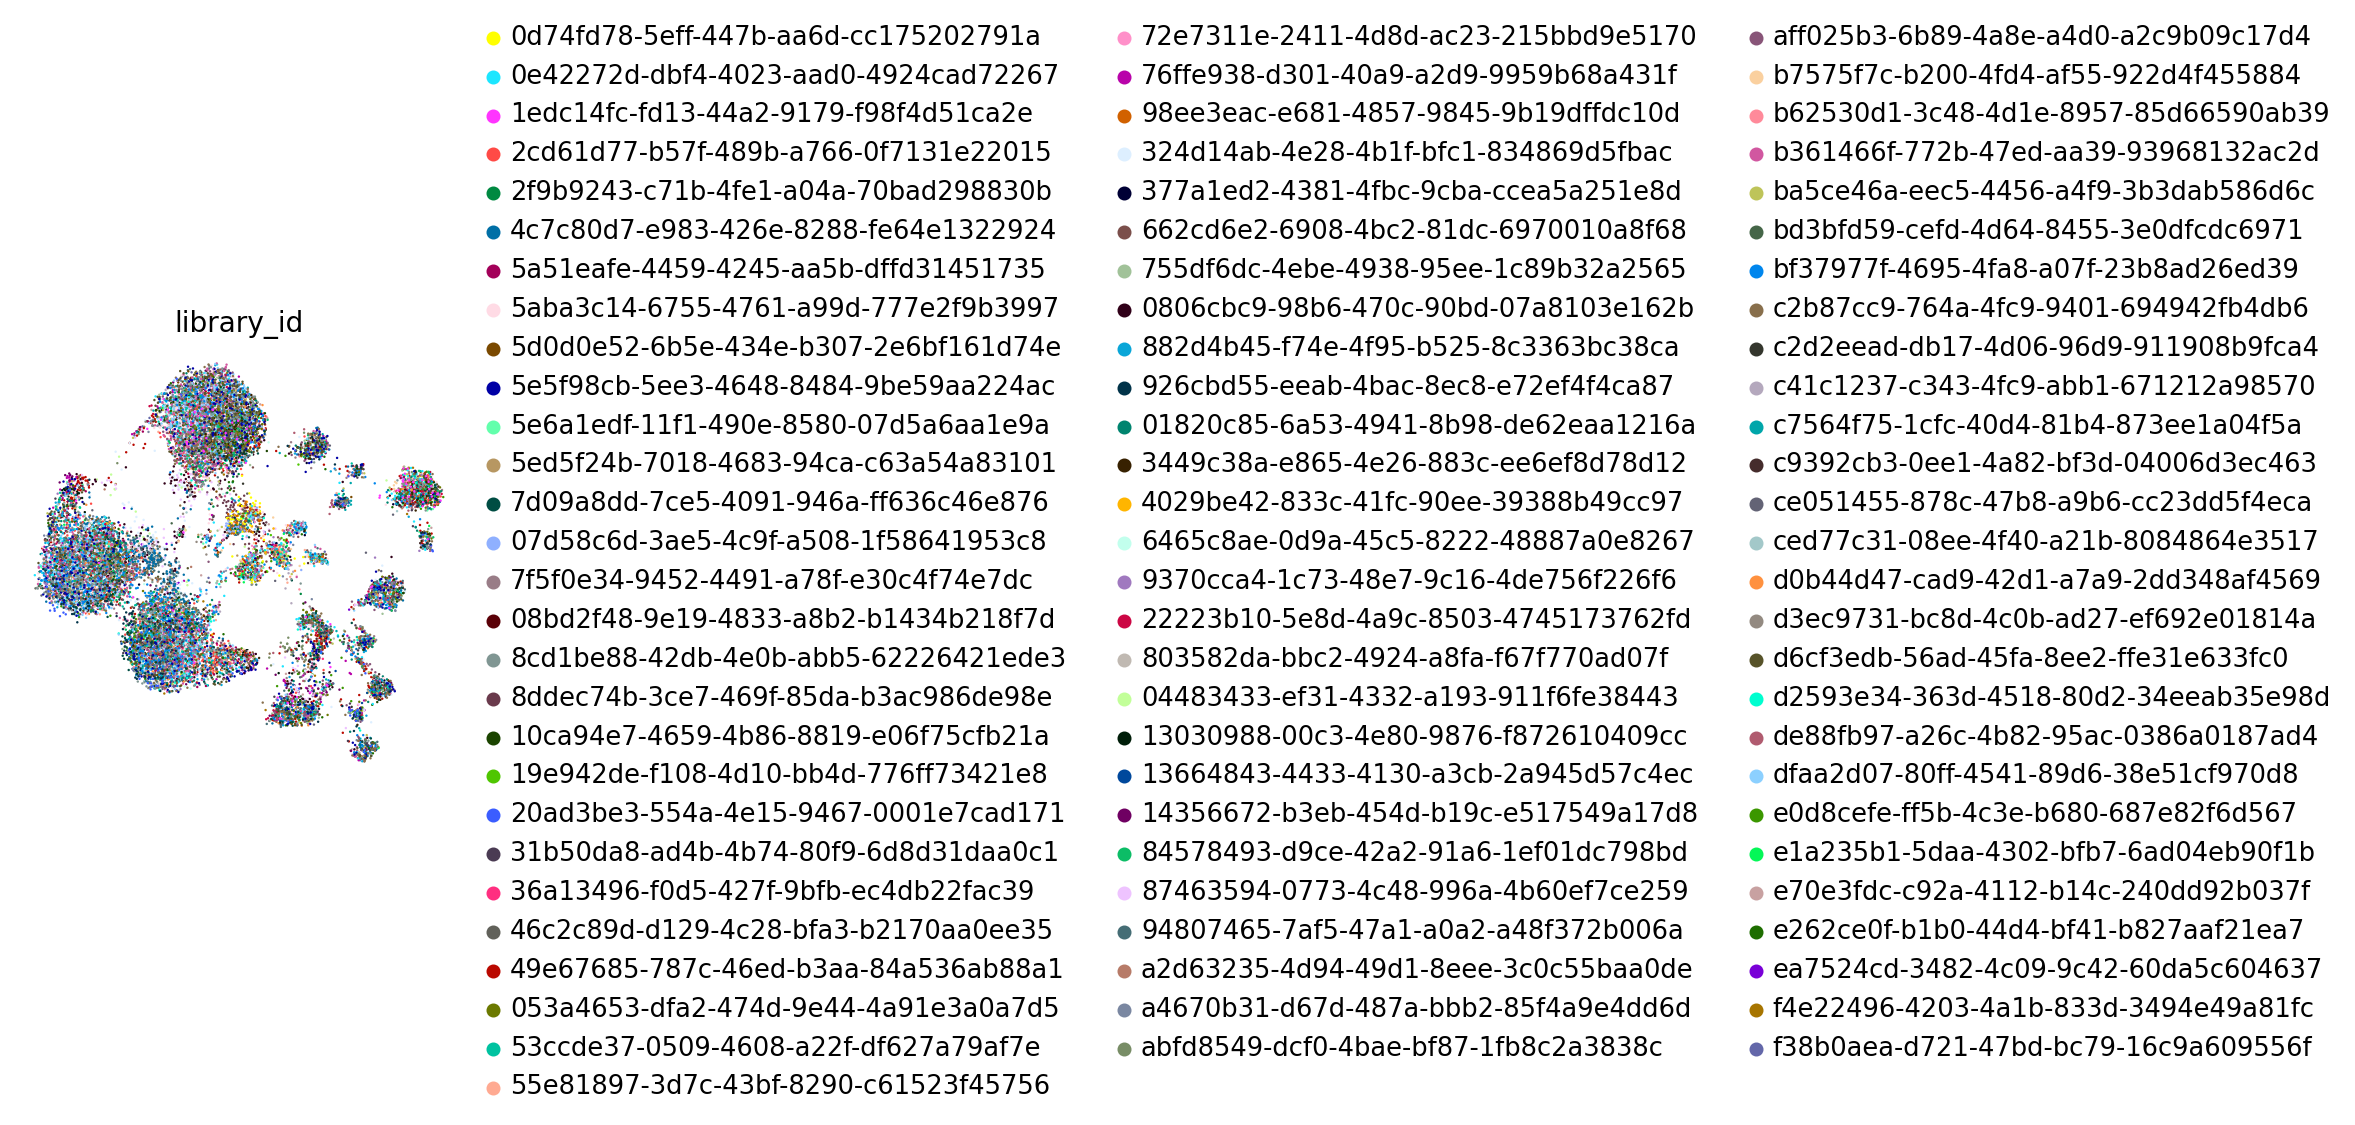

In [7]:
for color in colors:
    sc.pl.embedding(
        adata,
        'X_umap_scvi',
        color=color,
        frameon=False,
    )

# Preprocess data

Example of a simple preprocessing workflow with `scanpy`. Notably, the count matrices are stored as backed dask arrays, so that all subsequent operations will be executed lazily.
If you want to load any backed matrix in `adata` to memory, you can always use the `compute` command.

In [8]:
adata.layers['counts'] = adata.X.copy()

In [9]:
sc.pp.normalize_total(adata)

In [10]:
sc.pp.log1p(adata)

In [11]:
%%time
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

CPU times: user 4.93 s, sys: 877 ms, total: 5.81 s
Wall time: 5.75 s


In [12]:
%%time
sc.pp.pca(adata, n_comps=50, mask_var='highly_variable')

CPU times: user 41.3 s, sys: 922 ms, total: 42.2 s
Wall time: 13.8 s


In [13]:
%%time
sc.pp.neighbors(adata, use_rep='X_pca')

CPU times: user 30.7 s, sys: 2.78 s, total: 33.4 s
Wall time: 32.1 s


In [14]:
%%time
sc.tl.umap(adata)

CPU times: user 1min 24s, sys: 200 ms, total: 1min 24s
Wall time: 14 s


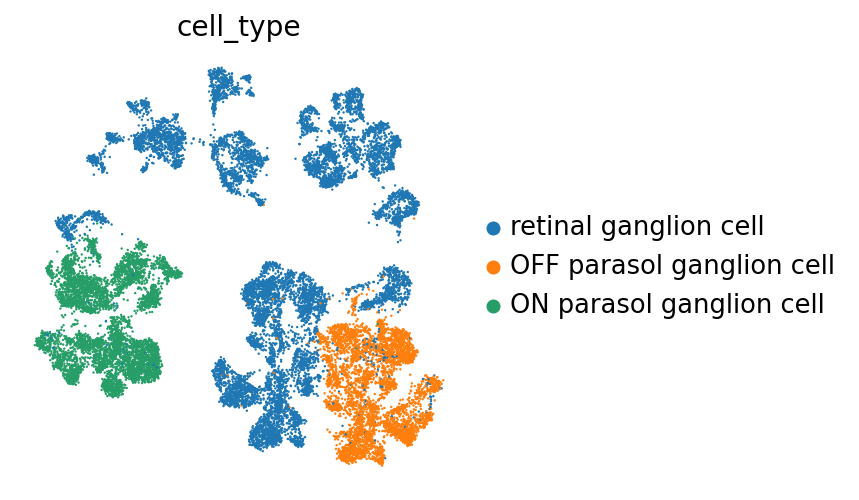

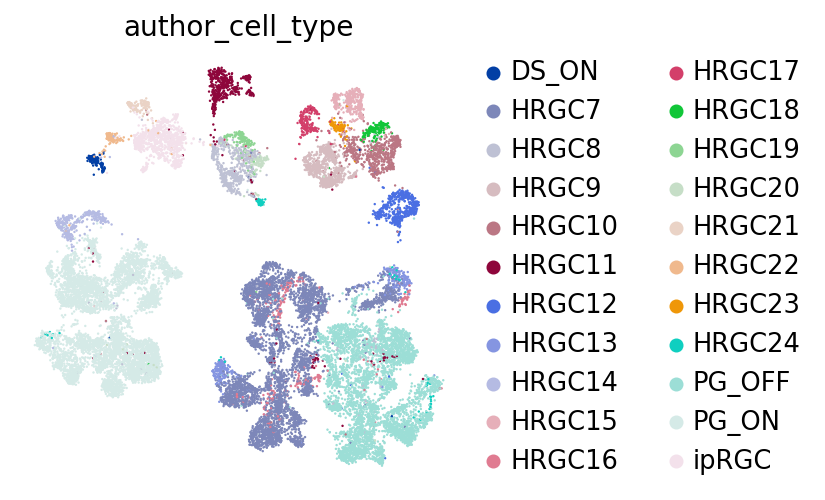

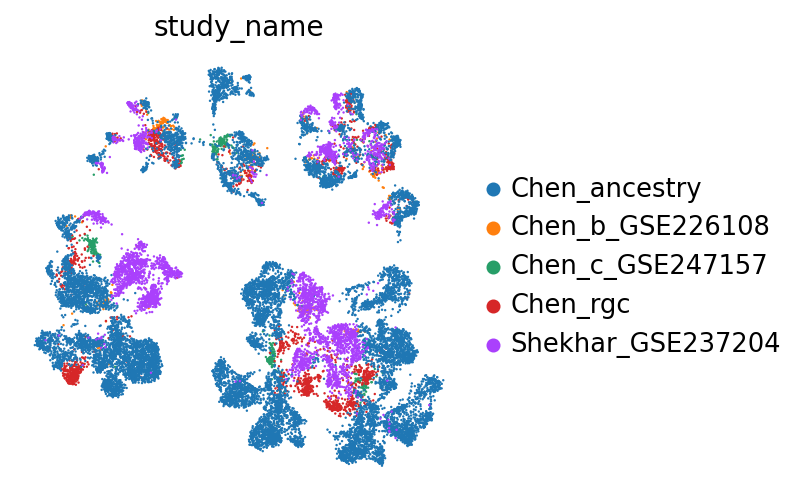

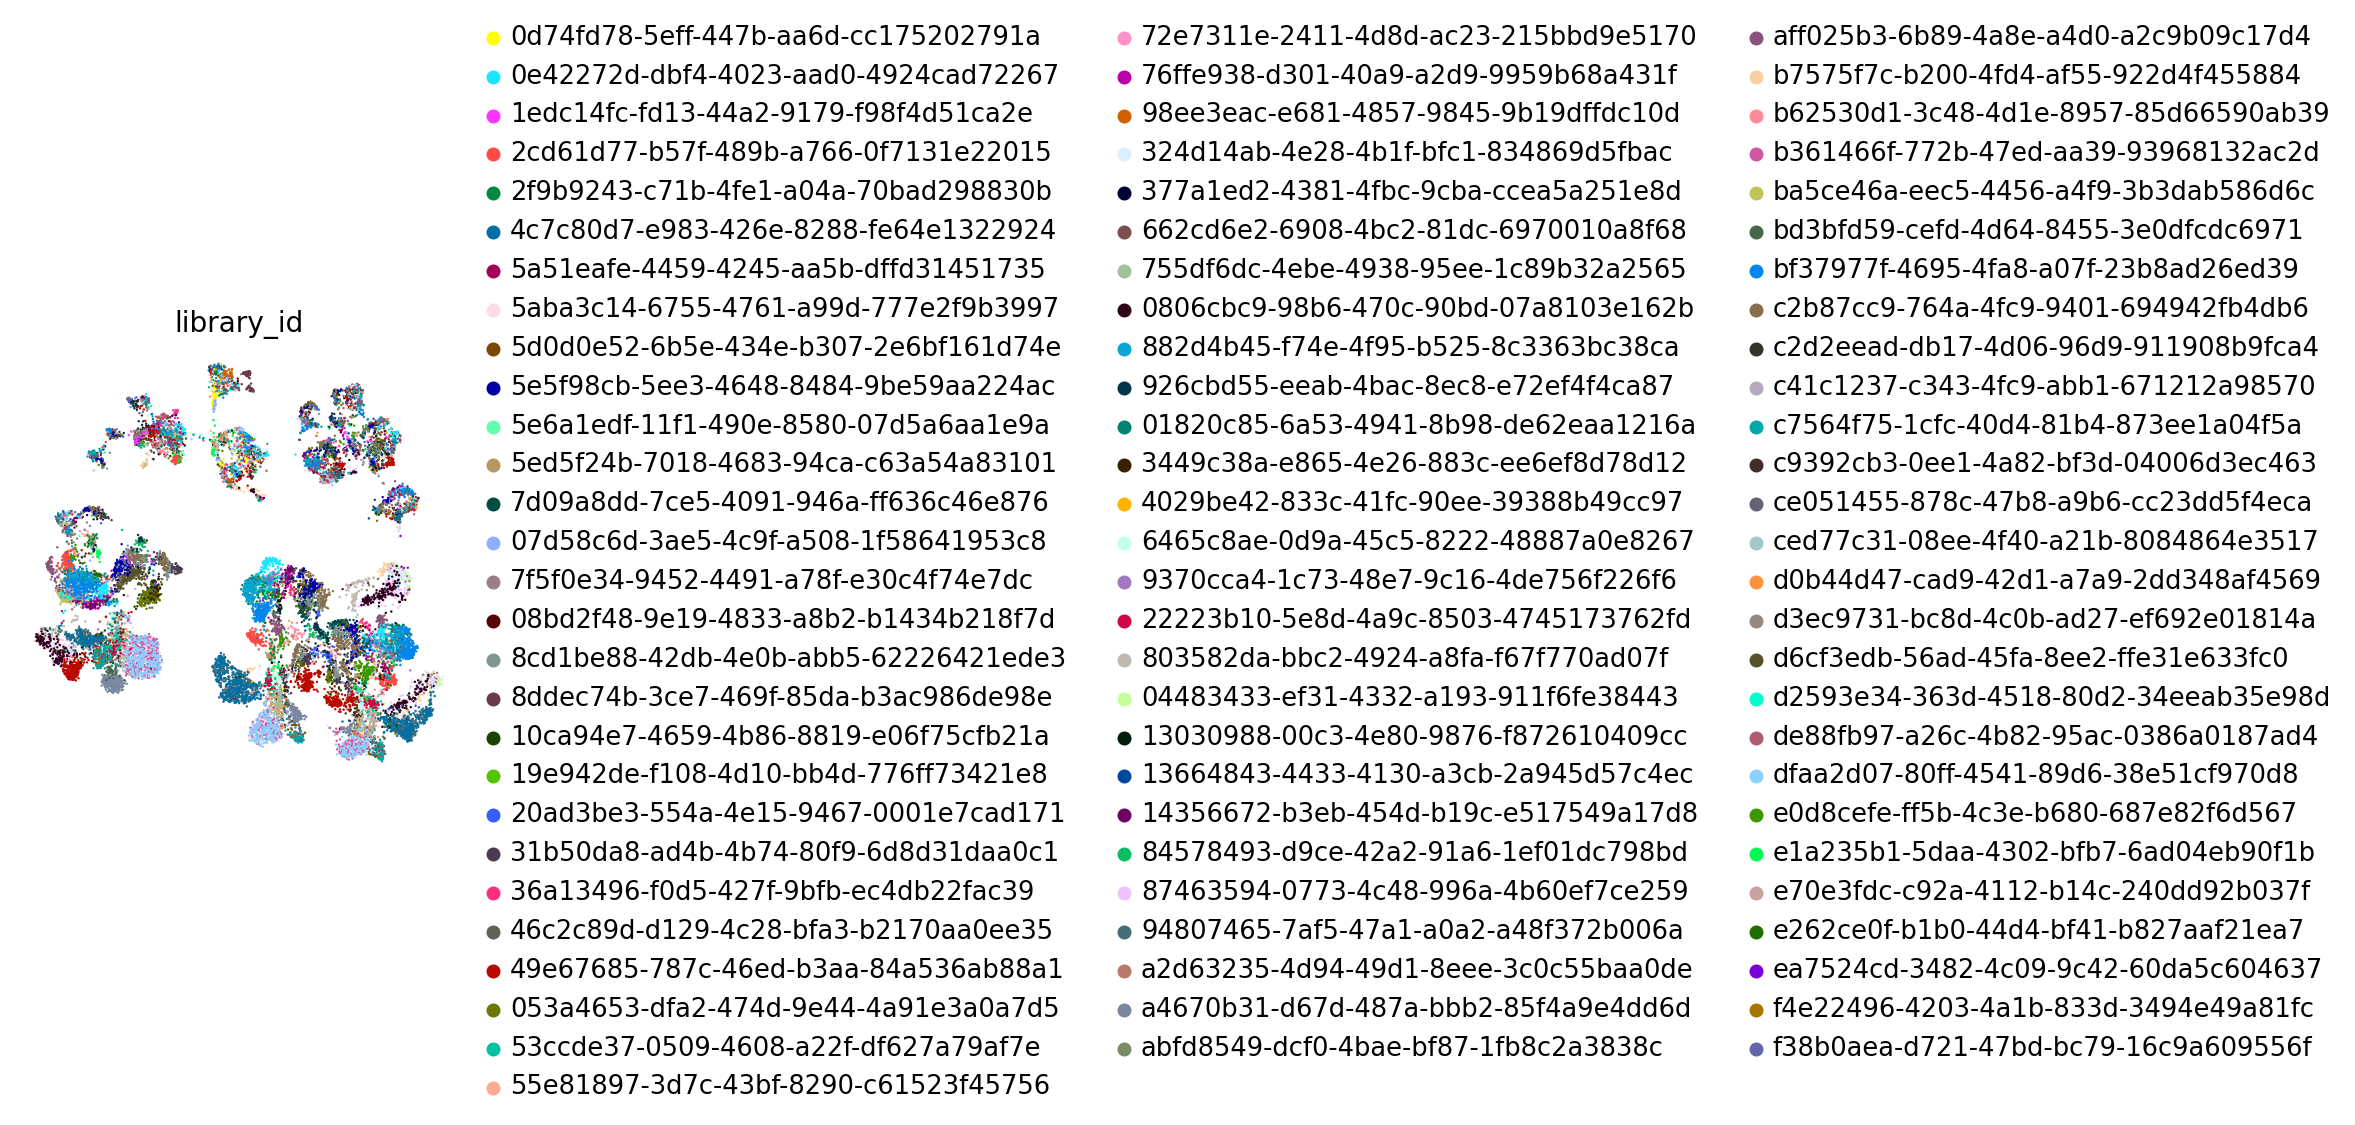

In [15]:
for color in colors:
    sc.pl.umap(
        adata,
        color=color,
        ncols=1,
        frameon=False,
    )

In [16]:
%%time
adata.write_zarr(f'data/{dataset_name}_preprocessed.zarr')

CPU times: user 8.71 s, sys: 2.59 s, total: 11.3 s
Wall time: 9.86 s
